# Marketing Mix Modeling: Channel Contributions and Budget Implications

## Scenario
Following the MMM baseline, you will extract channel-level contribution signals
from the model coefficients and translate them into a directional budget recommendation
for the growth team. This requires both technical output (ranked channel table and chart)
and responsible framing of the MMM's limitations.

## Your task
You will produce:
1. A ranked channel coefficient table (sorted by magnitude)
2. A horizontal bar chart of channel coefficients
3. A written directional budget recommendation that:
   - Names the top 1–2 channels to prioritize
   - Includes the **exact required caveat**: "MMM results are correlational (directional), not causal."
   - Notes what validation step you would recommend before making large reallocations

## Requirements
- Use `marketing_weekly_channels.csv`; refit the MMM (same setup as baseline exercise)
- Extract coefficients for adstock columns only (not time controls)
- Required caveat sentence must appear verbatim in your recommendation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from pathlib import Path
PROJECT_DIR = Path(r"/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project")
DATA_DIR = PROJECT_DIR / "Project_Data"
if not DATA_DIR.exists():
    DATA_DIR = Path("Project_Data")

CHOICE_PATH  = DATA_DIR / "choice_conjoint_tasks.csv"
BUNDLES_PATH = DATA_DIR / "candidate_bundles.csv"
ADOPT_PATH   = DATA_DIR / "observational_offer_adoption.csv"
SURVEY_PATH  = DATA_DIR / "survey_value_drivers.csv"
MMM_PATH     = DATA_DIR / "marketing_weekly_channels.csv"
print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: /content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project/Project_Data


In [3]:
# ── Step 1: Load data and refit the MMM ──────────────────────────────────
df = pd.read_csv(MMM_PATH, parse_dates=['week_start'])
df = df.sort_values('week_start').reset_index(drop=True)
df['t'] = np.arange(len(df))
df['sin52'] = np.sin(2 * np.pi * df['t'] / 52)
df['cos52'] = np.cos(2 * np.pi * df['t'] / 52)

channels = ['spend_search','spend_social','spend_video','spend_affiliate','spend_email']

def adstock(series, alpha=0.3):
    result = np.zeros(len(series))
    result[0] = series.iloc[0]
    for i in range(1, len(series)):
        result[i] = series.iloc[i] + alpha * result[i - 1]
    return result

for ch in channels:
    df[f'{ch}_adstock'] = adstock(df[ch])

adstock_cols  = [f'{ch}_adstock' for ch in channels]
feature_cols  = ['t','sin52','cos52'] + adstock_cols
X = df[feature_cols]
y = df['weekly_revenue_usd']
n_train = int(len(df) * 0.8)

# Refit Ridge on training period
model_mmm = Ridge(alpha=1.0)
model_mmm.fit(X.iloc[:n_train], y.iloc[:n_train])
print("Model fit. Test MAE:", round(mean_absolute_error(y.iloc[n_train:], model_mmm.predict(X.iloc[n_train:])), 2))

Model fit. Test MAE: 6280.84


In [4]:
# ── Step 2: Extract and rank channel coefficients ─────────────────────────
# Ridge coefficients: larger positive value = stronger positive association with revenue
all_coefs = pd.Series(model_mmm.coef_, index=feature_cols)
channel_coefs = all_coefs[adstock_cols].sort_values(ascending=False)

# Clean display names
channel_coefs.index = [c.replace('_adstock', '') for c in channel_coefs.index]
print("Channel coefficients (directional; higher = stronger revenue association):")
print(channel_coefs.round(4))

Channel coefficients (directional; higher = stronger revenue association):
spend_video        0.1491
spend_search       0.1210
spend_social       0.0183
spend_affiliate   -1.1596
spend_email       -1.9494
dtype: float64


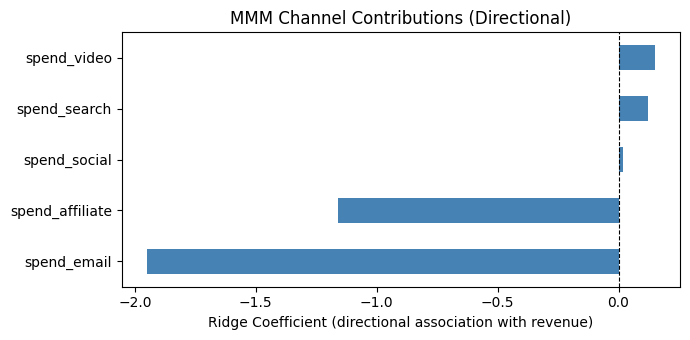

In [5]:
# ── Step 3: Channel coefficient chart ─────────────────────────────────────
plt.figure(figsize=(7, 3.5))
channel_coefs.sort_values().plot(kind='barh', color='steelblue')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Ridge Coefficient (directional association with revenue)")
plt.title("MMM Channel Contributions (Directional)")
plt.tight_layout()
plt.show()

## Budget Recommendation

In the markdown cell below, write a directional budget recommendation.
Your recommendation **must**:
1. Name the **top 1–2 channels** to prioritize (by coefficient magnitude/sign)
2. Include this exact sentence: **"MMM results are correlational (directional), not causal."**
3. Recommend a validation step before making large reallocation decisions
   (e.g., holdout test, geo-split experiment)

Keep the recommendation to 3–5 sentences.

In [6]:
# Print top channels to support the recommendation
top_channel = channel_coefs.idxmax()
second_channel = channel_coefs.index[1] if len(channel_coefs) > 1 else None
print(f"Top channel by coefficient: {top_channel}  ({channel_coefs[top_channel]:.4f})")
if second_channel:
    print(f"2nd channel:               {second_channel}  ({channel_coefs[second_channel]:.4f})")
print()
print("--- Example recommendation ---")
print(f"Based on the MMM, {top_channel} shows the strongest positive association with")
print(f"weekly revenue after controlling for time trend and carryover.")
print(f"A directional reallocation toward {top_channel} (and {second_channel}) is supported.")
print("MMM results are correlational (directional), not causal.")
print("Before making large budget changes, validate with a holdout geo-split or incrementality test.")

Top channel by coefficient: spend_video  (0.1491)
2nd channel:               spend_search  (0.1210)

--- Example recommendation ---
Based on the MMM, spend_video shows the strongest positive association with
weekly revenue after controlling for time trend and carryover.
A directional reallocation toward spend_video (and spend_search) is supported.
MMM results are correlational (directional), not causal.
Before making large budget changes, validate with a holdout geo-split or incrementality test.
